In [1]:
# Example 2: Stability admittance matrix with power distribution ratios
# Connect to PowerFactory, extract network, build Y-matrix, run load flow
import sys

PF_PYTHON_API_PATH = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4\Python\3.11" # Path to PowerFactory Python API
sys.path.insert(0, PF_PYTHON_API_PATH)
import powerfactory as pf

# Connect to PowerFactory
app = pf.GetApplicationExt()

# Import PFD file and initialize project
from admittance_matrix.utils import import_pfd_file

pfd_file_project = "Test_9_Bus.pfd" # File path to the PFD file
pfd_project_name = "Test_9_Bus" # IntPrj name
import_pfd_file(app, pfd_file_project, pfd_project_name)  # Change to your project
app.Show()

AttributeError: 'NoneType' object has no attribute 'Activate'

In [5]:
import pandas as pd
from admittance_matrix import Network

# Create network and build matrices
net = Network(app, base_mva=100.0)
net.run_load_flow()

Network extracted:
  Lines:              20
  Switches:           1
  Generators:         21
  Loads:              21
  Buses:              22


True

In [6]:
# Calculate power distribution ratios (returns ratios and matching gen names)
DIST_GEN = "SG 11"  # <-- Enter generator name here
MODE = 1
ratios, sources_name_order, sources_types = net.calculate_power_ratios(DIST_GEN, MODE)

Excluding source admittance for SG 11


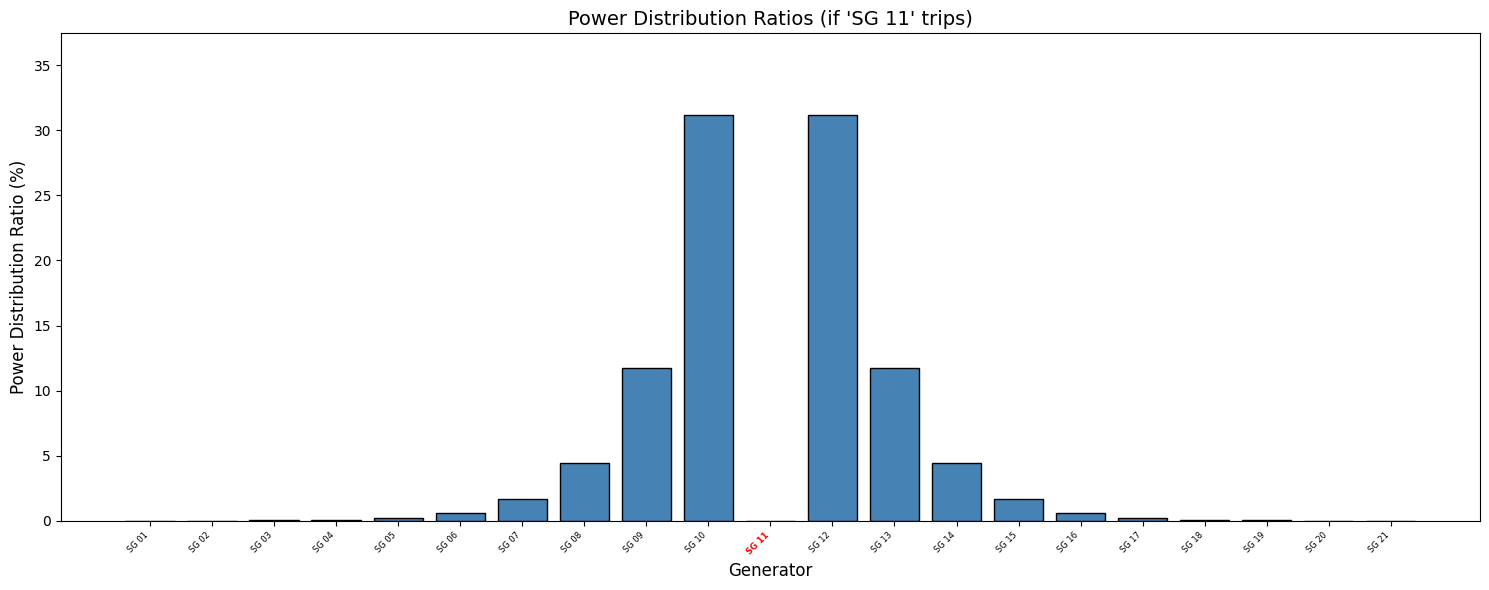

In [7]:
import matplotlib.pyplot as plt

# Create bar chart of power distribution ratios
fig, ax = plt.subplots(figsize=(15, 6))

bars = ax.bar(sources_name_order, ratios * 100, color='steelblue', edgecolor='black')

ax.set_xlabel('Generator', fontsize=12)
ax.set_ylabel('Power Distribution Ratio (%)', fontsize=12)
ax.set_title(f"Power Distribution Ratios (if '{DIST_GEN}' trips)", fontsize=14)
ax.set_ylim(0, max(ratios * 100) * 1.2 if max(ratios) > 0 else 10)

# Color the tripped generator label in red
plt.xticks(rotation=45, ha='right', fontsize=6)
for label in ax.get_xticklabels():
    if label.get_text() == DIST_GEN:
        label.set_color('red')
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()